# Parameter Estimation DAE
To do parameter estimation, we use yeast growth model from previous [example](<../Simulation DAE>).
For parameter estimation we need: model and experimental data.
Time grid is not needed, it will be build automatically based on provided data.
Model is defined exactly as in previous section.

## Model creation

In [1]:
import mopeds
import numpy as np
import matplotlib.pyplot as plt

variable_list = mopeds.variables.VariableList()

variable_list.add_variable(mopeds.VariableState("x1", 5, 0, 10))
variable_list.add_variable(mopeds.VariableState("x2", 0.01))
variable_list.add_variable(mopeds.VariableAlgebraic("r", 1.7))
variable_list.add_variable(mopeds.VariableControl("u1", 0.125, 0.05, 0.2))
variable_list.add_variable(mopeds.VariableControl("u2", 35, 5, 35))

variable_list.add_variable(mopeds.VariableParameter("theta1", 0.310, 1e-2, 2))
variable_list.add_variable(mopeds.VariableParameter("theta2", 0.180, 1e-2, 20))
variable_list.add_variable(mopeds.VariableParameter("theta3", 0.550, 1e-2, 2))
variable_list.add_variable(mopeds.VariableParameter("theta4", 0.050, 1e-2, 2))

m = mopeds.Model(variable_list)

x1 = m.varlist_all["x1"].casadi_var
x2 = m.varlist_all["x2"].casadi_var
r = m.varlist_all["r"].casadi_var
u1 = m.varlist_all["u1"].casadi_var
u2 = m.varlist_all["u2"].casadi_var

theta1 = m.varlist_all["theta1"].casadi_var
theta2 = m.varlist_all["theta2"].casadi_var
theta3 = m.varlist_all["theta3"].casadi_var
theta4 = m.varlist_all["theta4"].casadi_var

eq_alg1 = r - (theta1 * x2 / (theta2 + x2))

eq1 = (r - u1 - theta4)  * x1
eq2 = - (r * x1 / theta3) + u1 * (u2 - x2)

m.add_equations_differential([eq1, eq2])
m.add_equations_algebraic([eq_alg1])

## Providing data

Data has to be supplied in a variable list for each time trajectory. Use top level function `set_dataframe_from_value_and_time` for that.

As in [NLE PE](<../Parameter Estimation NLE>), parameters that have to be optimized should be unfixed.

In [2]:
data = [
    [5, 7.098, 10.135, 12.108, 12.491],
    [0.01, 6.683, 5.860, 3.209, 2.993]
]

exp_data = []

time_grid = [0, 5, 10, 15, 20]
variable_list["x1"].set_dataframe_from_value_and_time(data[0], time_grid)
variable_list["x2"].set_dataframe_from_value_and_time(data[1], time_grid)

variable_list["theta1"].fixed = False
variable_list["theta2"].fixed = False
variable_list["theta3"].fixed = False
variable_list["theta4"].fixed = False

pe = mopeds.ParameterEstimation(m, [variable_list])
res_pe = pe.optimize()
print("Estimated parameters", res_pe["x_dict"])


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:        0
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:       10

Total number of variables............................:        4
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        4
                     variables with only upper bounds:        0
Total number of equality constraints.................:        0
Total number of inequality c

## Plotting results

There are different ways to plot the results of parameter estimation. For example, one can use only information stored in `pe` object.

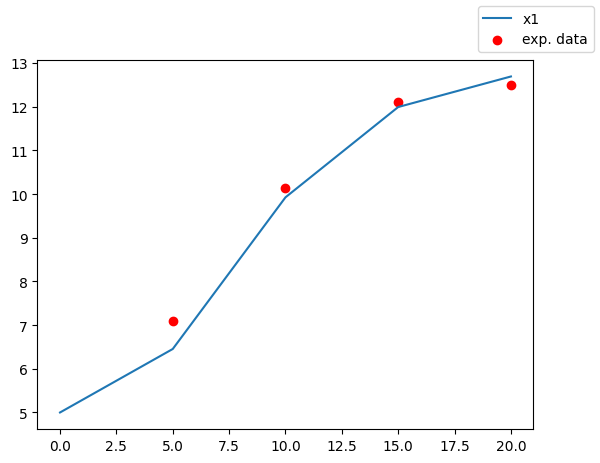

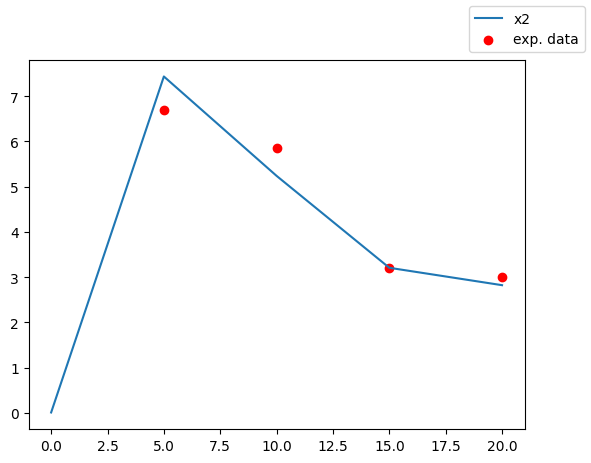

In [3]:
sim_data = pe.calculate_objective_and_residual(res_pe["x_dict"])["y"]
exp_data = pe.array_data

for var_index in [0, 1]:
    plt.figure()
    time_grid = pe.list_simulators[0].time_grid_relative
    value_at_time0 = pe.list_simulators[0]._initial_state[var_index]
    all_simulated_values = np.insert(sim_data[:,var_index], 0, value_at_time0)
    fig = plt.plot(time_grid, all_simulated_values, label=pe.names_of_measurements[var_index])
    plt.scatter(time_grid[1:], exp_data[:,var_index], c="r", label="exp. data")
    plt.figlegend()

To have more control, one can create a simulation object with given time grid, for that one needs to supply correct parameter variables.

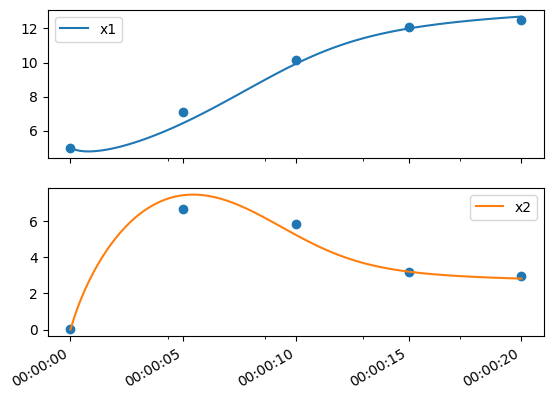

In [4]:
sim = mopeds.Simulator(m, np.linspace(0,20,100), variable_list)

#sim.change_independent_variables(res_pe["x_dict"])
res_sim = sim.generate_exp_data(unfixed_variables=res_pe["x_dict"])
axes = res_sim.plot(show=False)
for meas_index, meas_name in enumerate(pe.names_of_measurements):
    axes[meas_index].scatter(x=variable_list[meas_name].time_absolute, y=variable_list[meas_name].value )

plt.show()